# Polycrystalline gold digital twin

This twin revives the original atomistic polycrystalline slab as a Tango microscope. Random grain centers divide a **200 nm × 200 nm × 10 nm** sample into Voronoi grains. Each occupied grain contains explicit FCC gold atoms aligned within 2° of a primitive zone-axis family whose indices are no greater than 2; selected grains are empty. On the first acquisition at a field of view, the atoms are projected onto the scan grid and cached; later acquisitions reuse that raw potential and convolve it with the probe supplied by `DigitalTwinCorrector`.

Acquisitions use the normal scan API and are saved through the data server to Tiled.


## Start the digital twin

From the repository root:

```bash
uv sync --extra diffraction
uv run python startup_scripts/run_servers.py --yaml configs/polycrystalline_gold.yaml
```

Leave that terminal open while using the notebook.


In [18]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyTEMlib.image_tools as image_tools
import pyTEMlib.probe_tools as probe_tools
import tango
from IPython.display import display
from matplotlib.collections import PolyCollection
from skimage.restoration import richardson_lucy
from tiled.client import from_uri

%matplotlib ipympl

TANGO_HOST = os.getenv("ASYNCROSCOPY_TANGO_HOST", "127.0.0.1:9094")
TILED_URL = os.getenv("ASYNCROSCOPY_TILED_URL", "http://127.0.0.1:9091")
os.environ["TANGO_HOST"] = TANGO_HOST


In [19]:
scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
corrector = tango.DeviceProxy("asyncroscopy/corrector/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in (scan, microscope, corrector, data):
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

client = from_uri(TILED_URL)


asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/corrector/default ON
asyncroscopy/data/default ON


## Inspect the generated slab

The server generates grain centers, empty-grain choices, and orientations once from `sample_seed`. It generates explicit FCC atoms for the active field of view during each acquisition.


In [20]:
corrector_info = json.loads(corrector.get_info())["result"]
assert corrector_info["simulation"] and corrector_info["model"] == "DigitalTwinCorrector"
display(pd.Series(corrector_info, name="value").to_frame())

volume_metadata = json.loads(microscope.get_volume_metadata())
grain_parameters = pd.DataFrame(json.loads(microscope.get_region_parameters()))
display(pd.Series(volume_metadata, name="value").to_frame())
display(grain_parameters)


,value
manufacturer,CEOS
model,DigitalTwinCorrector
connected,True
simulation,True


,value
sample_type,atomistic_polycrystalline_gold_slab
volume_size_xy_nm,200.0
volume_thickness_nm,10.0
grain_size_angstrom,10.0
lattice_constant_angstrom,4.08
grain_count,9549
occupied_grain_count,8117
empty_grain_count,1432
zone_axis_families,"[[0, 0, 1], [0, 1, 1], [0, 1, 2], [1, 1, 1], [..."
zone_axis_max_deviation_deg,2.0


,label,occupied,center_angstrom,zone_axis,zone_offset_deg,orientation_euler_deg,composition
0,1,True,"[556.3513173330987, 584.9218400022012, 79.6700...","[0, 1, 2]",0.626096,"[28.390711001266517, 0.2967635701742909, 27.11...",{'Au': 1.0}
1,2,True,"[720.4694409352747, 1007.6953440736547, 57.612...","[1, 2, 2]",1.071814,"[-47.414750101622644, -19.610760400631463, 43....",{'Au': 1.0}
2,3,True,"[1482.5009491350945, 1291.544384994811, 4.2054...","[1, 2, 2]",0.086041,"[14.074354322937387, -19.488154725586515, 45.0...",{'Au': 1.0}
3,4,True,"[1981.5704903658973, 1747.0148532414562, 66.93...","[1, 1, 2]",1.071480,"[-52.4282303429461, -23.17172148023772, 27.158...",{'Au': 1.0}
4,5,True,"[282.9931234137215, 660.9435061771609, 15.6134...","[1, 2, 2]",0.682976,"[-88.28575469371786, -19.483881636323257, 44.2...",{'Au': 1.0}
...,...,...,...,...,...,...,...
9544,9545,True,"[313.49382716067043, 366.3183087201818, 57.003...","[1, 2, 2]",0.865941,"[29.10136135763039, -19.64057531970663, 45.901...",{'Au': 1.0}
9545,9546,True,"[1975.7338527463626, 967.2584349006272, 66.124...","[0, 1, 2]",0.769013,"[75.25448207022677, -0.758449712888308, 26.438...",{'Au': 1.0}
9546,9547,True,"[1449.2874431249481, 1858.8336442204584, 24.80...","[1, 2, 2]",1.412656,"[-95.68267309186797, -18.6193649978599, 43.807...",{'Au': 1.0}
9547,9548,True,"[422.9642224588477, 1277.4435759108958, 52.296...","[1, 1, 2]",0.764322,"[-105.70260636835394, -24.82580450506882, 26.8...",{'Au': 1.0}


## Acquire a corrector-driven defocus series

A 20 nm field of view resolves the differently oriented grains. Every image is saved to Tiled and returned as its own data key.


In [21]:
# takes ~45 seconds first time. ~2 seconds after that
# (will take longer when you change imsize or fov)

In [48]:
scan.imsize = 1024
scan.dwell_time = 10e-6
scan.scan_region = [0.0, 0.0, 1.0, 1.0]
microscope.set_fov(20e-9)

defocus_nm = np.array([0,1])
images = []
rows = []

for value_nm in defocus_nm:
    microscope.set_defocus(float(value_nm * 1e-9))
    key = microscope.acquire_scanned_image(["HAADF"])
    image = np.asarray(client[key]["image"]["HAADF"].read(), dtype=np.float64)
    images.append(image)
    rows.append({"defocus_nm": value_nm, "data_key": key, "mean": image.mean(), "standard_deviation": image.std()})

images = np.asarray(images)
defocus_results = pd.DataFrame(rows)
display(defocus_results)


,defocus_nm,data_key,mean,standard_deviation
0,0,stem_image_HAADF_20260811T200052968075.h5,0.363844,0.102492
1,1,stem_image_HAADF_20260811T200053642192.h5,0.364161,0.102871


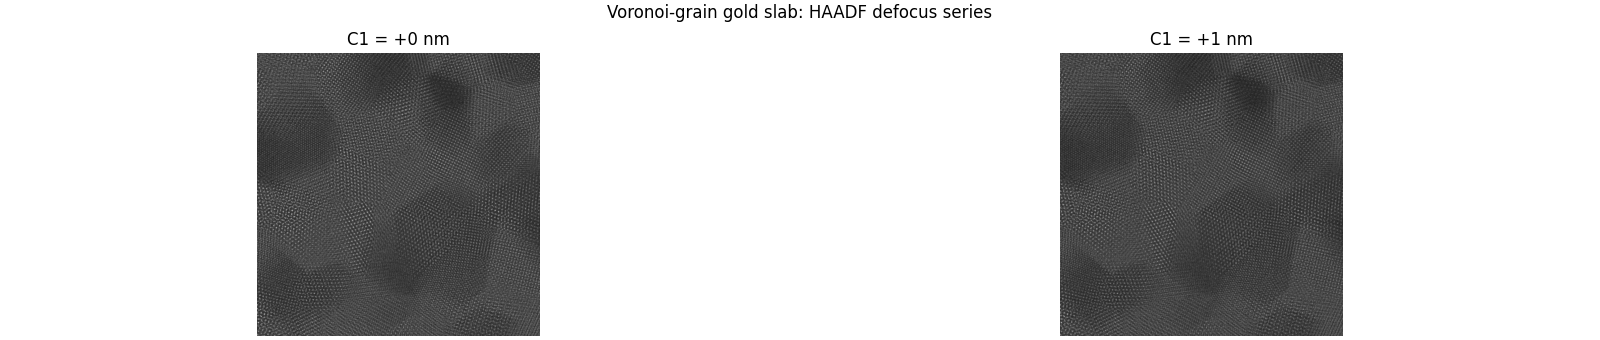

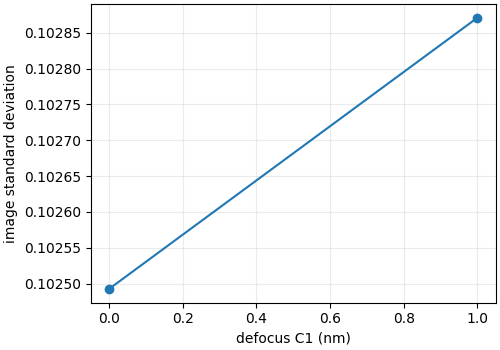

In [49]:
fig, axes = plt.subplots(1, len(defocus_nm), figsize=(16, 3.4), constrained_layout=True)
vmin, vmax = np.percentile(images, [1, 99])
for axis, value_nm, image in zip(axes, defocus_nm, images):
    axis.imshow(image, cmap="gray")
    axis.set_title(f"C1 = {value_nm:+.0f} nm")
    axis.axis("off")
fig.suptitle("Voronoi-grain gold slab: HAADF defocus series")
plt.show()

fig, axis = plt.subplots(figsize=(5, 3.5), constrained_layout=True)
axis.plot(defocus_results["defocus_nm"], defocus_results["standard_deviation"], "o-")
axis.set(xlabel="defocus C1 (nm)", ylabel="image standard deviation")
axis.grid(alpha=0.25)
plt.show()


## Fit the defocus contrast parabola

The raw sample potential remains cached while only the corrector coefficients change. Contrast here is the image standard deviation divided by its mean. Adjust `defocus_sweep_nm` to widen or tighten the search.

In [50]:
baseline_aberrations = json.loads(corrector.get_aberrations_coeff_sim())
defocus_sweep_nm = np.linspace(-8.0, 8.0, 9)
defocus_sweep_rows = []

for value_nm in defocus_sweep_nm:
    coefficients = {name: list(values) for name, values in baseline_aberrations.items()}
    coefficients["C1"] = [float(value_nm * 1e-9)]
    corrector.set_aberrations_coeff_sim(json.dumps(coefficients))
    key = microscope.acquire_scanned_image(["HAADF"])
    image = np.asarray(client[key]["image"]["HAADF"].read(), dtype=np.float64)
    contrast = image.std() / image.mean()
    defocus_sweep_rows.append({"defocus_nm": value_nm, "contrast": contrast, "data_key": key})

corrector.set_aberrations_coeff_sim(json.dumps(baseline_aberrations))
defocus_sweep_results = pd.DataFrame(defocus_sweep_rows)
parabola = np.polyfit(defocus_sweep_results["defocus_nm"], defocus_sweep_results["contrast"], 2)
parabola_x_nm = np.linspace(defocus_sweep_nm.min(), defocus_sweep_nm.max(), 300)
best_defocus_nm = -parabola[1] / (2.0 * parabola[0])
display(defocus_sweep_results)

,defocus_nm,contrast,data_key
0,-8.0,0.213558,stem_image_HAADF_20260811T200057022989.h5
1,-6.0,0.215036,stem_image_HAADF_20260811T200057698183.h5
2,-4.0,0.232412,stem_image_HAADF_20260811T200058346783.h5
3,-2.0,0.286519,stem_image_HAADF_20260811T200058995653.h5
4,0.0,0.281693,stem_image_HAADF_20260811T200059645624.h5
5,2.0,0.271274,stem_image_HAADF_20260811T200100291889.h5
6,4.0,0.227074,stem_image_HAADF_20260811T200100937947.h5
7,6.0,0.217473,stem_image_HAADF_20260811T200101583343.h5
8,8.0,0.213104,stem_image_HAADF_20260811T200102232900.h5


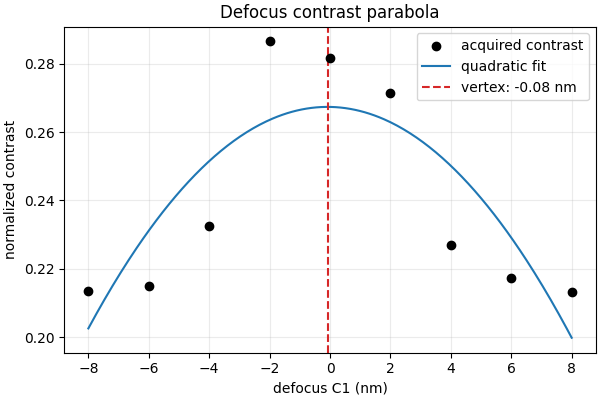

In [51]:
fig, axis = plt.subplots(figsize=(6, 4), constrained_layout=True)
axis.scatter(defocus_sweep_results["defocus_nm"], defocus_sweep_results["contrast"], color="black", label="acquired contrast", zorder=3)
axis.plot(parabola_x_nm, np.polyval(parabola, parabola_x_nm), label="quadratic fit")
axis.axvline(best_defocus_nm, color="tab:red", linestyle="--", label=f"vertex: {best_defocus_nm:.2f} nm")
axis.set(xlabel="defocus C1 (nm)", ylabel="normalized contrast", title="Defocus contrast parabola")
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## Hexagonal A1 grid search

The two A1 components are sampled on a triangular lattice, so their Voronoi cells are regular hexagons that tile without gaps. Change `a1_step_nm` or `a1_rings` to control the spacing and search radius.

In [54]:
baseline_aberrations = json.loads(corrector.get_aberrations_coeff_sim())
a1_step_nm = 1.0
a1_rings = 3
a1_rows = []

for q in range(-a1_rings, a1_rings + 1):
    for r in range(-a1_rings, a1_rings + 1):
        if abs(q + r) > a1_rings:
            continue
        a1_x_nm = a1_step_nm * (q + r / 2.0)
        a1_y_nm = a1_step_nm * np.sqrt(3.0) * r / 2.0
        coefficients = {name: list(values) for name, values in baseline_aberrations.items()}
        coefficients["A1"] = [float(a1_x_nm * 1e-9), float(a1_y_nm * 1e-9)]
        corrector.set_aberrations_coeff_sim(json.dumps(coefficients))
        key = microscope.acquire_scanned_image(["HAADF"])
        image = np.asarray(client[key]["image"]["HAADF"].read(), dtype=np.float64)
        a1_rows.append({"A1_x_nm": a1_x_nm, "A1_y_nm": a1_y_nm, "contrast": image.std() / image.mean(), "data_key": key})

corrector.set_aberrations_coeff_sim(json.dumps(baseline_aberrations))
a1_results = pd.DataFrame(a1_rows)
display(a1_results.sort_values("contrast", ascending=False).head())

,A1_x_nm,A1_y_nm,contrast,data_key
18,0.0,0.000000,0.294848,stem_image_HAADF_20260811T200148138208.h5
25,1.0,0.000000,0.291992,stem_image_HAADF_20260811T200152687017.h5
24,0.5,-0.866025,0.290660,stem_image_HAADF_20260811T200152032600.h5
12,-0.5,0.866025,0.285135,stem_image_HAADF_20260811T200144247555.h5
11,-1.0,0.000000,0.284248,stem_image_HAADF_20260811T200143601198.h5


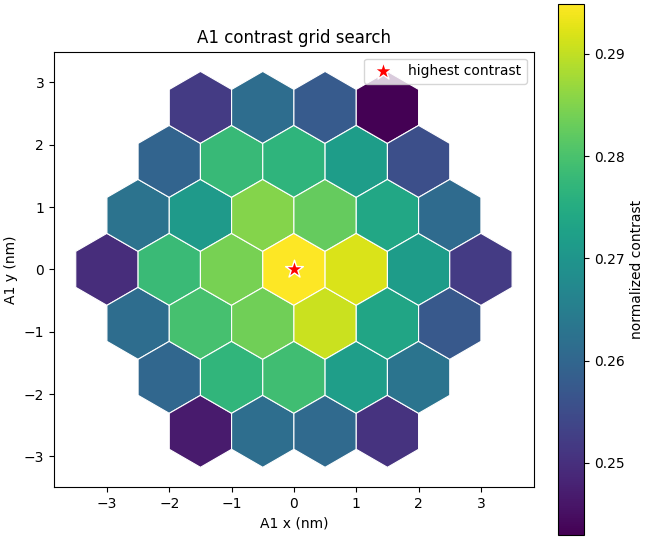

In [55]:
hexagon_radius_nm = a1_step_nm / np.sqrt(3.0)
hexagon_angles = np.deg2rad(np.arange(0.0, 360.0, 60.0) + 30.0)
hexagons = [np.column_stack((row.A1_x_nm + hexagon_radius_nm * np.cos(hexagon_angles), row.A1_y_nm + hexagon_radius_nm * np.sin(hexagon_angles))) for row in a1_results.itertuples()]
best_a1 = a1_results.loc[a1_results["contrast"].idxmax()]

fig, axis = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
collection = PolyCollection(hexagons, array=a1_results["contrast"].to_numpy(), cmap="viridis", edgecolors="white", linewidths=0.8)
axis.add_collection(collection)
axis.scatter(best_a1["A1_x_nm"], best_a1["A1_y_nm"], marker="*", s=180, color="red", edgecolor="white", label="highest contrast", zorder=3)
axis.autoscale_view()
axis.set_aspect("equal")
axis.set(xlabel="A1 x (nm)", ylabel="A1 y (nm)", title="A1 contrast grid search")
axis.legend()
fig.colorbar(collection, ax=axis, label="normalized contrast")
plt.show()

## A2 through-focus images, deconvolution, and probe shapes

Set the two A2 components below, then acquire underfocus, focus, and overfocus images. Each image is deconvolved with the matching simulated probe. The last column shows a normalized crop around the center of that probe.

In [46]:
baseline_aberrations = json.loads(corrector.get_aberrations_coeff_sim())
a2_nm = np.array([20.0, 0.0])
through_focus_nm = np.array([-5.0, 0.0, 5.0])
through_focus_labels = ["underfocus", "focus", "overfocus"]
through_focus_images = []
through_focus_deconvolved = []
through_focus_probes = []
through_focus_rows = []

for label, defocus_value_nm in zip(through_focus_labels, through_focus_nm):
    coefficients = {name: list(values) for name, values in baseline_aberrations.items()}
    coefficients["A2"] = [float(a2_nm[0] * 1e-9), float(a2_nm[1] * 1e-9)]
    coefficients["C1"] = [float(defocus_value_nm * 1e-9)]
    corrector.set_aberrations_coeff_sim(json.dumps(coefficients))
    key = microscope.acquire_scanned_image(["HAADF"])
    image = np.asarray(client[key]["image"]["HAADF"].read(), dtype=np.float64)

    edge_crop = max(12, int(round(0.06 * int(scan.imsize))))
    padded_size = int(scan.imsize) + 2 * edge_crop
    aberrations = probe_tools.get_target_aberrations("Spectra300", 200000)
    mappings = {"C1": ("C10",), "A1": ("C12a", "C12b"), "B2": ("C21a", "C21b"), "A2": ("C23a", "C23b"), "C3": ("C30",), "S3": ("C32a", "C32b"), "A3": ("C34a", "C34b"), "D4": ("C41a", "C41b"), "B4": ("C43a", "C43b"), "A4": ("C45a", "C45b")}
    for source, destinations in mappings.items():
        for destination, value_m in zip(destinations, coefficients[source]):
            aberrations[destination] = float(value_m * 1e9)
    aberrations["acceleration_voltage"] = 200000.0
    aberrations["FOV"] = 20
    aberrations["convergence_angle"] = 30.0
    aberrations["wavelength"] = image_tools.get_wavelength(aberrations["acceleration_voltage"])
    probe, _aperture, _chi = probe_tools.get_probe(aberrations, padded_size, padded_size, verbose=False)
    probe_center = padded_size // 2
    probe_kernel = probe[probe_center - 32:probe_center + 33, probe_center - 32:probe_center + 33]
    probe_kernel /= probe_kernel.sum()
    image_for_deconvolution = image - image.min()
    image_for_deconvolution /= image_for_deconvolution.max()
    deconvolved = richardson_lucy(image_for_deconvolution, probe_kernel, num_iter=20, clip=False)
    through_focus_images.append(image)
    through_focus_deconvolved.append(deconvolved)
    through_focus_probes.append(probe)
    through_focus_rows.append({"condition": label, "defocus_nm": defocus_value_nm, "A2_x_nm": a2_nm[0], "A2_y_nm": a2_nm[1], "data_key": key})

corrector.set_aberrations_coeff_sim(json.dumps(baseline_aberrations))
through_focus_results = pd.DataFrame(through_focus_rows)
display(through_focus_results)

,condition,defocus_nm,A2_x_nm,A2_y_nm,data_key
0,underfocus,-5.0,20.0,0.0,stem_image_HAADF_20260811T200024722804.h5
1,focus,0.0,20.0,0.0,stem_image_HAADF_20260811T200026439947.h5
2,overfocus,5.0,20.0,0.0,stem_image_HAADF_20260811T200028104293.h5


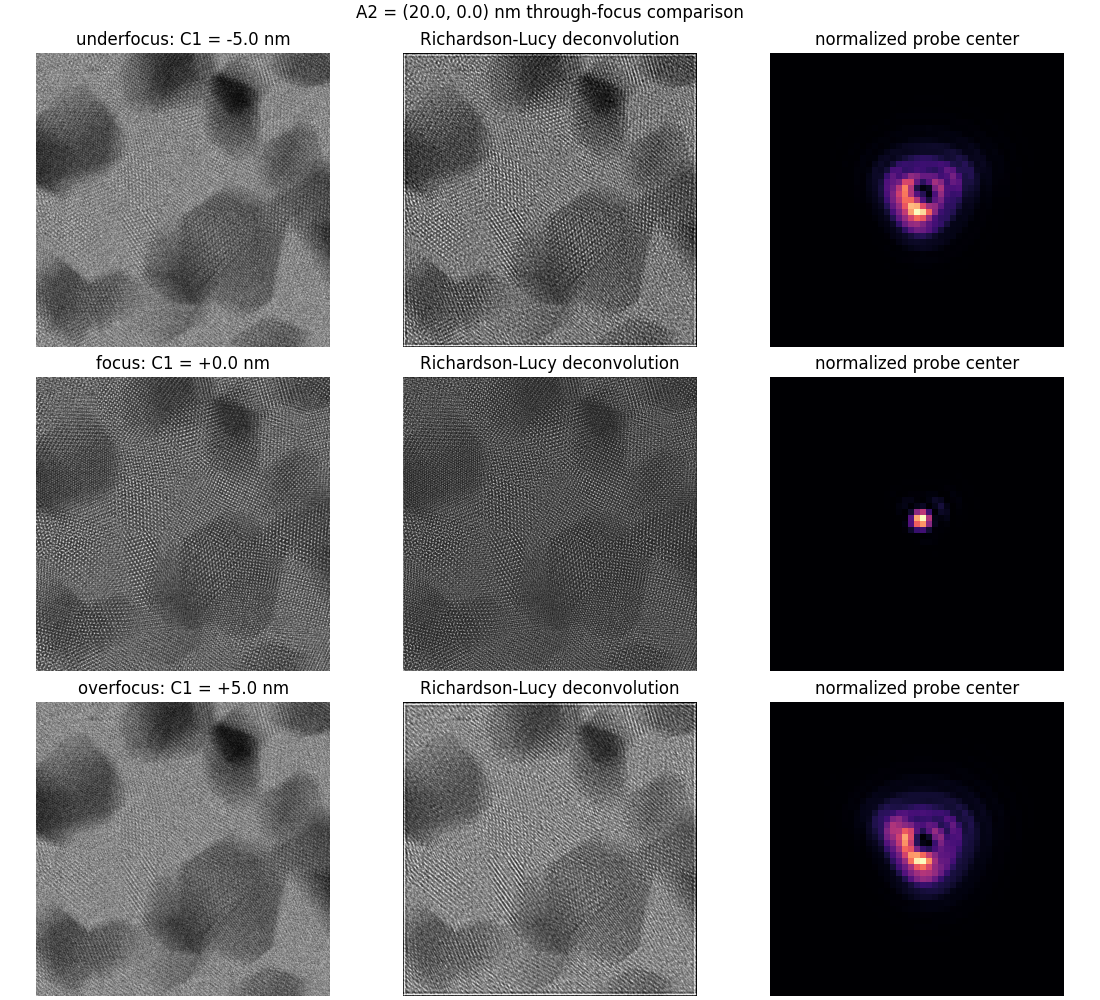

In [47]:
fig, axes = plt.subplots(3, 3, figsize=(11, 10), constrained_layout=True)
for row, label, defocus_value_nm, image, deconvolved, probe in zip(axes, through_focus_labels, through_focus_nm, through_focus_images, through_focus_deconvolved, through_focus_probes):
    probe_center = probe.shape[0] // 2
    probe_zoom = probe[probe_center - 24:probe_center + 25, probe_center - 24:probe_center + 25]
    row[0].imshow(image, cmap="gray", vmin=np.percentile(image, 1), vmax=np.percentile(image, 99))
    row[0].set_title(f"{label}: C1 = {defocus_value_nm:+.1f} nm")
    row[1].imshow(deconvolved, cmap="gray", vmin=np.percentile(deconvolved, 1), vmax=np.percentile(deconvolved, 99))
    row[1].set_title("Richardson-Lucy deconvolution")
    row[2].imshow(probe_zoom / probe_zoom.max(), cmap="magma", vmin=0.0, vmax=1.0)
    row[2].set_title("normalized probe center")
    for axis in row:
        axis.axis("off")
fig.suptitle(f"A2 = ({a2_nm[0]:.1f}, {a2_nm[1]:.1f}) nm through-focus comparison")
plt.show()